# Model A — Single-Frame Baseline (v2: reads packed HDF5)

Run after `week1_data_setup.ipynb` v2 has produced `train_crops.h5`, `val_crops.h5`, `test_crops.h5` in `CROPS_DIR`. No loose-file loading, no Drive I/O bottleneck.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_ROOT = '/content/drive/MyDrive/PIE_thesis'
CROPS_DIR = f'{DRIVE_ROOT}/crops'
RESULTS_DIR = f'{DRIVE_ROOT}/results'
CHECKPOINTS_DIR = f'{DRIVE_ROOT}/checkpoints'
for d in [RESULTS_DIR, CHECKPOINTS_DIR]:
    os.makedirs(d, exist_ok=True)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T
import numpy as np
import h5py
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import pandas as pd

device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
print('Device:', device)


Mounted at /content/drive
Device: cuda


## 2. Dataset: reads directly from packed HDF5

In [2]:
IMG_SIZE = 224
normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

class PIECropsDataset(Dataset):
    def __init__(self, h5_path):
        self.h5_path = h5_path
        with h5py.File(h5_path, 'r') as hf:
            self.length = hf['images'].shape[0]
        self._hf = None

    def _ensure_open(self):
        if self._hf is None:
            self._hf = h5py.File(self.h5_path, 'r')

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        self._ensure_open()
        img = self._hf['images'][idx]  # HWC uint8
        label = int(self._hf['labels'][idx])
        img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        img = normalize(img)
        return img, label

train_ds = PIECropsDataset(f'{CROPS_DIR}/train_crops.h5')
val_ds = PIECropsDataset(f'{CROPS_DIR}/val_crops.h5')
test_ds = PIECropsDataset(f'{CROPS_DIR}/test_crops.h5')
print('Dataset sizes:', len(train_ds), len(val_ds), len(test_ds))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)


Dataset sizes: 876 243 717


## 3. Class weights (from the HDF5 labels, no need to re-walk sequences)

In [3]:
with h5py.File(f'{CROPS_DIR}/train_crops.h5', 'r') as hf:
    train_labels = hf['labels'][:]

unique, counts = np.unique(train_labels, return_counts=True)
print('Train class distribution:', dict(zip(unique.tolist(), counts.tolist())))
class_weights = torch.tensor([len(train_labels) / c for c in counts], dtype=torch.float32).to(device)
print('Class weights:', class_weights)


Train class distribution: {0: 623, 1: 253}
Class weights: tensor([1.4061, 3.4625], device='cuda:0')


## 4. Model: MobileNetV2 classifier head

In [4]:
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.last_channel, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 128MB/s]


## 5. Train

In [5]:
EPOCHS = 10

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, n = 0.0, 0
    all_preds, all_labels = [], []
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train:
                optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            n += x.size(0)
            preds = out.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    return total_loss / max(n, 1), f1

history = []
for epoch in range(EPOCHS):
    train_loss, train_f1 = run_epoch(train_loader, train=True)
    val_loss, val_f1 = run_epoch(val_loader, train=False)
    print(f'Epoch {epoch+1}/{EPOCHS}  train_loss={train_loss:.4f} train_f1={train_f1:.4f}  val_loss={val_loss:.4f} val_f1={val_f1:.4f}')
    history.append({'epoch': epoch+1, 'train_loss': train_loss, 'train_f1': train_f1, 'val_loss': val_loss, 'val_f1': val_f1})

torch.save(model.state_dict(), f'{CHECKPOINTS_DIR}/model_a_mobilenetv2.pt')
print('Saved checkpoint')


Epoch 1/10  train_loss=0.6268 train_f1=0.5498  val_loss=0.6198 val_f1=0.4607
Epoch 2/10  train_loss=0.4151 train_f1=0.7820  val_loss=0.4926 val_f1=0.6032
Epoch 3/10  train_loss=0.2546 train_f1=0.8736  val_loss=0.4158 val_f1=0.6500
Epoch 4/10  train_loss=0.1529 train_f1=0.9371  val_loss=0.3768 val_f1=0.6792
Epoch 5/10  train_loss=0.1049 train_f1=0.9651  val_loss=0.3744 val_f1=0.6838
Epoch 6/10  train_loss=0.0617 train_f1=0.9901  val_loss=0.4185 val_f1=0.6504
Epoch 7/10  train_loss=0.0523 train_f1=0.9843  val_loss=0.3587 val_f1=0.7059
Epoch 8/10  train_loss=0.0353 train_f1=0.9922  val_loss=0.3689 val_f1=0.7308
Epoch 9/10  train_loss=0.0306 train_f1=0.9921  val_loss=0.3824 val_f1=0.6981
Epoch 10/10  train_loss=0.0139 train_f1=1.0000  val_loss=0.3946 val_f1=0.7129
Saved checkpoint


## 6. Evaluate on held-out test set

In [6]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = model(x)
        preds = out.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

f1 = f1_score(all_labels, all_preds, zero_division=0)
precision = precision_score(all_labels, all_preds, zero_division=0)
recall = recall_score(all_labels, all_preds, zero_division=0)
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()
fnr = fn / (fn + tp) if (fn + tp) > 0 else float('nan')
fpr = fp / (fp + tn) if (fp + tn) > 0 else float('nan')

results = {'model': 'Model A - Single-Frame MobileNetV2', 'f1': f1, 'precision': precision,
           'recall': recall, 'false_negative_rate': fnr, 'false_positive_rate': fpr}
print(results)
print(classification_report(all_labels, all_preds, target_names=['not-crossing', 'crossing']))


{'model': 'Model A - Single-Frame MobileNetV2', 'f1': 0.8144329896907216, 'precision': 0.8633879781420765, 'recall': 0.7707317073170732, 'false_negative_rate': np.float64(0.22926829268292684), 'false_positive_rate': np.float64(0.048828125)}
              precision    recall  f1-score   support

not-crossing       0.91      0.95      0.93       512
    crossing       0.86      0.77      0.81       205

    accuracy                           0.90       717
   macro avg       0.89      0.86      0.87       717
weighted avg       0.90      0.90      0.90       717



## 7. Figures

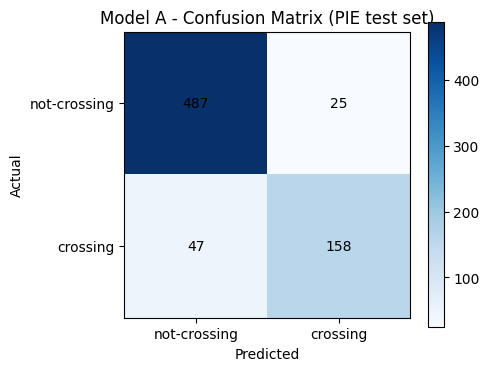

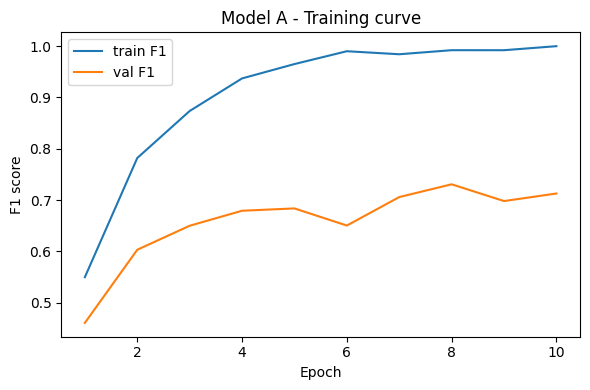

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['not-crossing', 'crossing'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['not-crossing', 'crossing'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Model A - Confusion Matrix (PIE test set)')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.colorbar(im)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/model_a_confusion_matrix.png', dpi=150)
plt.show()

metrics_df = pd.DataFrame([results])
metrics_df.to_csv(f'{RESULTS_DIR}/model_a_test_metrics.csv', index=False)
history_df = pd.DataFrame(history)
history_df.to_csv(f'{RESULTS_DIR}/model_a_training_history.csv', index=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_df['epoch'], history_df['train_f1'], label='train F1')
ax.plot(history_df['epoch'], history_df['val_f1'], label='val F1')
ax.set_xlabel('Epoch'); ax.set_ylabel('F1 score')
ax.set_title('Model A - Training curve')
ax.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/model_a_training_curve.png', dpi=150)
plt.show()
